In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
import uuid
from dotenv import load_dotenv
from langgraph.runtime import Runtime
from langchain.embeddings import init_embeddings
from dataclasses import dataclass

load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

f:\langchain\campusz\graph\langgraph\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
embeddings = init_embeddings("google_genai:gemini-embedding-001")

store = InMemoryStore(
    index = {
        "embed": embeddings,
        "fields": ["memory", "$"],
    }
)
checkpointer = InMemorySaver()

In [3]:
@dataclass
class Context:
    user_id: str

In [ ]:
async def update_memory(state: MessagesState, runtime: Runtime[Context]):

    #MessagesState is default state provide in which it has reducer field named messages by which it can remember all history of messages
    user_id = runtime.context.user_id
    namespace = (user_id, "memories")

    last_message = state["messages"][-1].content
    memory_id = str(uuid.uuid4())

    await runtime.store.aput(
        namespace,
        memory_id,
        {"memory": last_message},
        index=["memory"]  # Only embed this field
    )
    return state

In [5]:
async def call_model(state: MessagesState, runtime: Runtime[Context]):

    user_id = runtime.context.user_id
    namespace = (user_id, "memories")

    # Semantic search
    memories = await runtime.store.asearch(
        namespace,
        query=state["messages"][-1].content,
        limit=3
    )

    info = "\n".join([m.value["memory"] for m in memories])

    # Build prompt with memory context
    prompt = f"""
    You are a helpful assistant.

    Relevant memories about this user:
    {info}

    User message:
    {state["messages"][-1].content}

    Use memories if relevant.
    """

    response = await model.ainvoke(prompt)

    state["messages"].append(
        {"role": "assistant", "content": response.content}
    )

    return state

In [6]:
graph = StateGraph(MessagesState, context_schema=Context)

graph.add_node("update_memory", update_memory)
graph.add_node("call_model", call_model)

graph.add_edge(START, "update_memory")
graph.add_edge("update_memory", "call_model")
graph.add_edge("call_model", END)

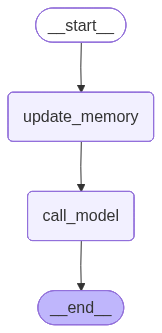

In [7]:
workflow = graph.compile(checkpointer=checkpointer, store=store)
workflow

In [8]:
config = {"configurable": {"thread_id": "1"}}

async def run_chat(message):
    async for event in workflow.astream(
        {"messages": [{"role": "user", "content": message}]},
        config,
        stream_mode="updates",
        context=Context(user_id="1"),
    ):
        if "call_model" in event:
            messages = event["call_model"]["messages"]
            
            last_msg = messages[-1]
            
            if isinstance(last_msg, dict):
                print("\nAssistant:", last_msg["content"])
            else:
                print("\nAssistant:", last_msg.content)

await run_chat("I love Italian food")

NumPy not found in the current Python environment. The InMemoryStore will use a pure Python implementation for vector operations, which may significantly impact performance, especially for large datasets or frequent searches. For optimal speed and efficiency, consider installing NumPy: pip install numpy



Assistant: That's great! I remember you mentioned that. It's a fantastic cuisine. Do you have any favorite dishes or types of Italian food?


In [9]:
await run_chat("What food do I like?")


Assistant: You love Italian food!


In [10]:
config2 = {"configurable": {"thread_id": "2"}}

async def run_chat_thread2(message):
    async for event in workflow.astream(
        {"messages": [{"role": "user", "content": message}]},
        config2,
        stream_mode="updates",
        context=Context(user_id="1"),  # same user_id
    ):
        if "call_model" in event:
            messages = event["call_model"]["messages"]
            
            last_msg = messages[-1]
            
            if isinstance(last_msg, dict):
                print("\nAssistant:", last_msg["content"])
            else:
                print("\nAssistant:", last_msg.content)

await run_chat_thread2("Tell me about my memories")


Assistant: Here are the memories I have about you:
*   You love Italian food.
*   You've previously asked "What food do I like?".
